<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/FPDP_Engine_Earthquake_Boundary_State_Adapter_v0_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FPDP Engine — Earthquake Boundary-State Adapter v0.2
## Canonical Refactor of FUNt Earthquake Transition Ledger v1.1

**Flow • Potential Difference • Persistence**

Historical / descriptive analysis only. **No prediction performed.**

This notebook preserves the operational behavior of:

```text
FUNt_Earthquake_Transition_Ledger_v1_1_Visual_Repair
```

It refactors the notebook into the canonical FPDP adapter architecture without intentionally changing the validated earthquake ledger mathematics.

---

## Canonical dependency graph

```text
FUNt
   ↓ defines
FPDP Mathematics
   ↓ implemented by
FPDP Engine
   ↓ executes
FPDP History Analysis
   ↓ generates
History Plot Against h³π and Ψ
   ↓ supported by
Earthquake Boundary-State Adapter
   ↓ produces
Standard Outputs
```

## Machine-readable architecture

```yaml
Theory:
  name: FUNt
  relationship: defines

Mathematics:
  name: FPDP Mathematics
  definition: Flow • Potential Difference • Persistence
  relationship: implemented by

Engine:
  name: FPDP Engine
  relationship: executes

Primary Analysis:
  name: FPDP History Analysis
  visualization: History Plot Against h³π and Ψ

Adapter:
  name: Earthquake Boundary-State Adapter
  role: translate USGS earthquake catalog observations into canonical FPDP quantities

Outputs:
  - SITREP
  - History Plot
  - Audit
```


## Adapter Contract

Every FPDP adapter must translate domain observations into canonical FPDP fields.

### Required canonical fields

```text
time
flow
potential_difference
boundary_state
persistence
```

### Earthquake Boundary-State Adapter fields

```text
flow                  -> strain transport / aftershock release activity
potential_difference  -> H0-normalized seismic energy imbalance
boundary_state        -> admissible crust/fault boundary-state allowance
persistence           -> residual strain / persistence ledger
fpdp_pressure         -> transition strain / release pressure proxy
```

### Rule

The adapter may use domain-specific variables, but the FPDP Engine should process canonical fields.


## Beginner Note

If you can raise children, run a household, operate a car, troubleshoot burnt toast, wire a barn, repair a pump, or rebuild a carburetor, you can learn this notebook.

The software isn't smarter than you—it simply speaks a different language.

Like any language, it becomes familiar one step at a time.

You do not need to become a programmer to use this engine. You only need curiosity, patience, and a willingness to learn.


## README: How to Run This Notebook

1. Open this `.ipynb` file in Google Colab.
2. Click **Runtime → Run all**.
3. Let each cell finish before judging the result.
4. The notebook retrieves the configured USGS mainshock and aftershock catalog.
5. If no aftershocks are returned, lower `min_magnitude` or increase `max_radius_km`.

### File rule

```text
.ipynb = notebook / dashboard / run buttons
.py    = engine code / import file / do not open as notebook
.csv   = saved observations or run log
.json  = SITREP, audit, or dependency graph
.png   = saved plots
```

Most users only need the `.ipynb` notebook.


## Continuity / Migration Note

This is an architectural refactor, not a mathematical rewrite.

Preserved from FUNt Earthquake Transition Ledger v1.1 — Visual Repair Edition:

1. USGS mainshock retrieval by event ID.
2. H = 0 mainshock reference.
3. Aftershock catalog retrieval by radius, time window, and magnitude threshold.
4. Gutenberg-Richter event energy estimate.
5. Hourly persistence ledger.
6. Fibonacci/hHRT window ledger.
7. Relaxation ledger.
8. Spatial distance-band ledger.
9. Diagnostics and visual repairs.
10. CSV, PNG, summary report, and ZIP export.

**Research rule:** this notebook must not be tuned to a single event.


## Version Ledger

| Version | Role |
|---|---|
| v1.1 | FUNt Earthquake Transition Ledger — Visual Repair Edition |
| v0.1 | FPDP Earthquake Boundary-State Model schema / wrapper |
| v0.2 | Canonical FPDP adapter refactor preserving v1.1 ledger mathematics |

No mathematical retuning is introduced in v0.2.


## Notebook Philosophy

Every run should answer five reader questions:

1. **What happened?** Mainshock and aftershock sequence.
2. **Why is it being measured this way?** H = 0, elapsed time, energy, persistence, Fibonacci/hHRT windows, and boundary state.
3. **How did the model decide?** Ledger columns, SITREP, audit, and diagnostics.
4. **What should be watched next?** Historical residuals and boundary-state terms only.
5. **What is Nature teaching?** Persistent systems release, relax, and reorganize under boundary conditions.

The Earthquake Boundary-State Adapter translates domain-specific observations into FPDP language. The FPDP Engine processes the canonical quantities.


In [1]:
# ============================================================
# FPDP Engine — Earthquake Boundary-State Adapter v0.2
# Visual Repair Edition
# Historical / descriptive analysis only. No prediction performed.
# ============================================================

import requests
import json
import hashlib
import os
import zipfile
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print("Imports complete.")

VERSION = "fpdp-earthquake-boundary-state-adapter-v0.2"
ORIGINAL_IMPLEMENTATION = "FUNt Earthquake Transition Ledger v1.1 Visual Repair Edition"
UTC_NOW = datetime.now(timezone.utc)
print("FPDP Engine — Earthquake Boundary-State Adapter", VERSION)
print("Original implementation:", ORIGINAL_IMPLEMENTATION)
print("Run UTC:", UTC_NOW.isoformat())


Imports complete.
FPDP Engine — Earthquake Boundary-State Adapter fpdp-earthquake-boundary-state-adapter-v0.2
Original implementation: FUNt Earthquake Transition Ledger v1.1 Visual Repair Edition
Run UTC: 2026-06-29T20:08:51.806538+00:00


## Boundary Conditions

These prevent the notebook from becoming a curve-fitting toy.

### 1. Historical boundary
Use only earthquake catalog information available within the configured historical window.

### 2. H = 0 boundary
The configured USGS mainshock is the reference event.

### 3. Persistence boundary
One aftershock is not a transition law. Persistence requires survival across repeated windows and multiple sequences.

### 4. Boundary-state rule
Boundary state is exposed as a canonical field, but v0.2 does not yet couple solar weather, atmospheric pressure, hydrology, or tides.

### 5. Prediction boundary
This notebook is historical and descriptive only.

### 6. Humility boundary
If Nature disagrees with the model, the model is revised, not Nature.


## Configuration

Change only this block for a new earthquake sequence.

In [2]:
CONFIG = {
    "notebook_version": "FPDP Engine — Earthquake Boundary-State Adapter v0.2",
    "event_id": "us6000t7zp",       # Venezuela mainshock; replace with any USGS event ID
    "min_magnitude": 4.0,
    "max_radius_km": 500,
    "days_after_mainshock": 30,
    "hourly_bin_size_hours": 1,
    "rolling_window_hours": 6,
    "survival_windows_x": 3,
    "distance_bands_km": [0, 100, 250, 500],
    "source": "USGS FDSN Event API",
    "theory": "FUNt",
    "mathematics": "FPDP Mathematics",
    "mathematics_definition": "Flow • Potential Difference • Persistence",
    "engine": "FPDP Engine",
    "adapter": "Earthquake Boundary-State Adapter",
    "primary_analysis": "FPDP History Analysis",
    "visualization": "History Plot Against h³π and Ψ",
    "prediction_mode": False
}

CONFIG_JSON = json.dumps(CONFIG, sort_keys=True)
CONFIG_HASH = hashlib.sha256(CONFIG_JSON.encode("utf-8")).hexdigest()

print("==== Audit Header ====")
print(json.dumps(CONFIG, indent=2))
print(f"\nConfig SHA-256: {CONFIG_HASH}")
print(f"Prediction mode: {CONFIG['prediction_mode']}")

==== Audit Header ====
{
  "notebook_version": "FPDP Engine \u2014 Earthquake Boundary-State Adapter v0.2",
  "event_id": "us6000t7zp",
  "min_magnitude": 4.0,
  "max_radius_km": 500,
  "days_after_mainshock": 30,
  "hourly_bin_size_hours": 1,
  "rolling_window_hours": 6,
  "survival_windows_x": 3,
  "distance_bands_km": [
    0,
    100,
    250,
    500
  ],
  "source": "USGS FDSN Event API",
  "theory": "FUNt",
  "mathematics": "FPDP Mathematics",
  "mathematics_definition": "Flow \u2022 Potential Difference \u2022 Persistence",
  "engine": "FPDP Engine",
  "adapter": "Earthquake Boundary-State Adapter",
  "primary_analysis": "FPDP History Analysis",
  "visualization": "History Plot Against h\u00b3\u03c0 and \u03a8",
  "prediction_mode": false
}

Config SHA-256: 98eb1f436a4df5a5d41245f1ba747fea5b8e4d4bb342b3e5200d4d9dd58547f9
Prediction mode: False


## 2. Helper Functions

In [3]:
def usgs_get_json(url, timeout=30):
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()


def mag_to_energy_joules(m):
    # Gutenberg-Richter energy estimate: E = 10^(1.5M + 4.8) Joules.
    if pd.isna(m):
        return np.nan
    return 10 ** (1.5 * float(m) + 4.8)


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def make_fibonacci_hours(max_hours):
    # Day-scaled Fibonacci windows: 1,2,3,5... days × 24 hours.
    fib_days = [1, 2]
    while fib_days[-1] * 24 < max_hours:
        fib_days.append(fib_days[-1] + fib_days[-2])
    return np.array([d * 24 for d in fib_days], dtype=float), fib_days


def nearest_fib_hour(h, fib_hours):
    if len(fib_hours) == 0 or pd.isna(h):
        return np.nan, np.nan
    k = int(np.argmin(np.abs(fib_hours - h)))
    return int(fib_hours[k]), float(h - fib_hours[k])


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)
    return path


def save_json(path, obj):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, default=str)


def write_text(path, text):
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)


def savefig(name, fig_dir):
    path = os.path.join(fig_dir, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")
    return path

print("Helper functions ready.")

Helper functions ready.


## 3. Mainshock Retrieval — H = 0 Reference

In [4]:
EVENT_ID = CONFIG["event_id"]
mainshock_url = "https://earthquake.usgs.gov/fdsnws/event/1/query?" + f"format=geojson&eventid={EVENT_ID}"

mainshock_geojson = usgs_get_json(mainshock_url)
main_props = mainshock_geojson["properties"]
main_coords = mainshock_geojson["geometry"]["coordinates"]

MAINSHOCK = {
    "event_id": EVENT_ID,
    "place": main_props.get("place"),
    "magnitude": main_props.get("mag"),
    "time_ms": main_props.get("time"),
    "time_utc": pd.to_datetime(main_props.get("time"), unit="ms", utc=True),
    "longitude": main_coords[0],
    "latitude": main_coords[1],
    "depth_km": main_coords[2],
    "url": main_props.get("url"),
}

print("==== Mainshock / H = 0 Reference ====")
for k, v in MAINSHOCK.items():
    print(f"{k}: {v}")

==== Mainshock / H = 0 Reference ====
event_id: us6000t7zp
place: 28 km SE of Yumare, Venezuela
magnitude: 7.5
time_ms: 1782338711566
time_utc: 2026-06-24 22:05:11.566000+00:00
longitude: -68.4716
latitude: 10.4351
depth_km: 10
url: https://earthquake.usgs.gov/earthquakes/eventpage/us6000t7zp


## 4. Event Folder

In [5]:
ROOT_DIR = ensure_dir("Earthquake_Transition_Ledger")
EVENT_DIR = ensure_dir(os.path.join(ROOT_DIR, EVENT_ID))
FIG_DIR = ensure_dir(os.path.join(EVENT_DIR, "figures"))

save_json(os.path.join(EVENT_DIR, "config.json"), CONFIG)
save_json(os.path.join(EVENT_DIR, "event.json"), MAINSHOCK)
write_text(os.path.join(EVENT_DIR, "SHA256.txt"), CONFIG_HASH + "\n")

print(f"Event folder: {EVENT_DIR}")
print(f"Figure folder: {FIG_DIR}")

Event folder: Earthquake_Transition_Ledger/us6000t7zp
Figure folder: Earthquake_Transition_Ledger/us6000t7zp/figures


## 5. Aftershock Catalog Retrieval

In [6]:
main_time = MAINSHOCK["time_utc"]
end_time = main_time + pd.Timedelta(days=CONFIG["days_after_mainshock"])

starttime = main_time.strftime("%Y-%m-%dT%H:%M:%S")
endtime = end_time.strftime("%Y-%m-%dT%H:%M:%S")

query_url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    f"format=geojson&starttime={starttime}&endtime={endtime}"
    f"&minmagnitude={CONFIG['min_magnitude']}"
    f"&latitude={MAINSHOCK['latitude']}&longitude={MAINSHOCK['longitude']}"
    f"&maxradiuskm={CONFIG['max_radius_km']}"
    "&orderby=time-asc"
)

retrieval_time_utc = datetime.now(timezone.utc).isoformat()
aftershock_geojson = usgs_get_json(query_url)
features = aftershock_geojson.get("features", [])

rows = []
rejected_mainshock = 0
rejected_before_h0 = 0

for f in features:
    fid = f.get("id")
    p = f.get("properties", {})
    g = f.get("geometry", {}).get("coordinates", [np.nan, np.nan, np.nan])
    event_time = pd.to_datetime(p.get("time"), unit="ms", utc=True)

    if fid == EVENT_ID:
        rejected_mainshock += 1
        continue
    if event_time < main_time:
        rejected_before_h0 += 1
        continue

    lon, lat, depth = g[0], g[1], g[2]
    distance_km = haversine_km(MAINSHOCK["latitude"], MAINSHOCK["longitude"], lat, lon)
    hours_since = (event_time - main_time).total_seconds() / 3600.0
    mag = p.get("mag")

    rows.append({
        "event_id": fid,
        "time_utc": event_time,
        "hours_since_H0": hours_since,
        "magnitude": mag,
        "energy_J": mag_to_energy_joules(mag),
        "place": p.get("place"),
        "latitude": lat,
        "longitude": lon,
        "depth_km": depth,
        "distance_km": distance_km,
        "usgs_url": p.get("url")
    })

df_events = pd.DataFrame(rows)

if not df_events.empty:
    df_events = df_events.sort_values("time_utc").reset_index(drop=True)
    df_events["cumulative_energy_J"] = df_events["energy_J"].cumsum()
    df_events["hour_bin"] = np.floor(df_events["hours_since_H0"]).astype(int)

print("==== Data Acquisition Audit ====")
print(f"USGS query: {query_url}")
print(f"Retrieval UTC: {retrieval_time_utc}")
print(f"Raw events retrieved: {len(features)}")
print(f"Rejected as mainshock: {rejected_mainshock}")
print(f"Rejected before H0: {rejected_before_h0}")
print(f"Aftershocks analyzed: {len(df_events)}")

if df_events.empty:
    print("WARNING: No aftershocks returned for this event/configuration. Try lowering min_magnitude or increasing max_radius_km.")
else:
    display(df_events.head(10))

==== Data Acquisition Audit ====
USGS query: https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2026-06-24T22:05:11&endtime=2026-07-24T22:05:11&minmagnitude=4.0&latitude=10.4351&longitude=-68.4716&maxradiuskm=500&orderby=time-asc
Retrieval UTC: 2026-06-29T20:08:52.120509+00:00
Raw events retrieved: 9
Rejected as mainshock: 1
Rejected before H0: 0
Aftershocks analyzed: 8


,event_id,time_utc,hours_since_H0,magnitude,energy_J,place,latitude,longitude,depth_km,distance_km,usgs_url,cumulative_energy_J,hour_bin
0,us6000t80d,2026-06-24 22:23:53.774000+00:00,0.311724,4.5,3.548134e+11,"12 km NNE of Caucagüito, Venezuela",10.5911,-66.6976,10,194.722559,https://earthquake.usgs.gov/earthquakes/eventp...,3.548134e+11,0
1,us6000t81p,2026-06-25 05:48:23.136000+00:00,7.719881,4.4,2.511886e+11,"5 km NE of Guatire, Venezuela",10.5111,-66.5057,10,215.122326,https://earthquake.usgs.gov/earthquakes/eventp...,6.060020e+11,7
2,us6000t8d1,2026-06-26 04:19:30.378000+00:00,30.238559,4.4,2.511886e+11,"17 km WSW of Morón, Venezuela",10.4537,-68.3607,10,12.302315,https://earthquake.usgs.gov/earthquakes/eventp...,8.571907e+11,30
3,us6000t8k6,2026-06-26 22:16:11.931000+00:00,48.183435,4.7,7.079458e+11,"54 km N of El Limón, Venezuela",10.8000,-67.5993,10,103.609954,https://earthquake.usgs.gov/earthquakes/eventp...,1.565136e+12,48
4,us6000t8q8,2026-06-27 19:20:36.606000+00:00,69.256956,4.8,1.000000e+12,"35 km NNE of El Limón, Venezuela",10.6023,-67.5112,10,106.630399,https://earthquake.usgs.gov/earthquakes/eventp...,2.565136e+12,69
5,us6000t8su,2026-06-28 08:46:10.376000+00:00,82.683003,4.5,3.548134e+11,"20 km W of Boca de Aroa, Venezuela",10.6806,-68.4901,10,27.373196,https://earthquake.usgs.gov/earthquakes/eventp...,2.919950e+12,82
6,us6000t8sx,2026-06-28 09:33:58.852000+00:00,83.479802,4.3,1.778279e+11,"19 km WSW of Morón, Venezuela",10.4497,-68.3766,10,10.514660,https://earthquake.usgs.gov/earthquakes/eventp...,3.097778e+12,83
7,us6000t8yf,2026-06-29 11:01:03.516000+00:00,108.931097,4.6,5.011872e+11,"27 km N of Caraballeda, Venezuela",10.8601,-66.8435,10,184.088240,https://earthquake.usgs.gov/earthquakes/eventp...,3.598965e+12,108


## 6. Ledgers

In [7]:
transition_csv = os.path.join(EVENT_DIR, "transition_ledger.csv")
aftershocks_csv = os.path.join(EVENT_DIR, "aftershocks.csv")
df_events.to_csv(transition_csv, index=False)
df_events.to_csv(aftershocks_csv, index=False)
print(f"Saved: {transition_csv}")
print(f"Saved: {aftershocks_csv}")

if df_events.empty:
    df_hourly = pd.DataFrame()
    df_fib = pd.DataFrame()
    df_relax = pd.DataFrame()
    df_spatial = pd.DataFrame()
else:
    max_hour = int(np.ceil(df_events["hours_since_H0"].max()))
    full_hours = pd.DataFrame({"hour": np.arange(0, max_hour + 1)})

    grouped = (
        df_events.groupby("hour_bin")
        .agg(
            event_count=("event_id", "count"),
            energy_J=("energy_J", "sum"),
            max_magnitude=("magnitude", "max"),
            mean_magnitude=("magnitude", "mean"),
            mean_depth_km=("depth_km", "mean"),
            mean_distance_km=("distance_km", "mean")
        )
        .rename_axis("hour")
        .reset_index()
    )

    df_hourly = full_hours.merge(grouped, on="hour", how="left")
    df_hourly[["event_count", "energy_J"]] = df_hourly[["event_count", "energy_J"]].fillna(0)
    df_hourly["cumulative_energy_J"] = df_hourly["energy_J"].cumsum()

    x = CONFIG["survival_windows_x"]
    df_hourly["active_window"] = df_hourly["event_count"] > 0
    df_hourly["survival_x_windows"] = df_hourly["active_window"].rolling(x, min_periods=x).sum() >= x

    max_hours = CONFIG["days_after_mainshock"] * 24
    fib_hours, fib_days = make_fibonacci_hours(max_hours)
    fib_rows = []
    prev_h = 0
    for day, h in zip(fib_days, fib_hours):
        window = df_events[(df_events["hours_since_H0"] > prev_h) & (df_events["hours_since_H0"] <= h)]
        fib_rows.append({
            "fib_day_marker": day,
            "fib_hour_marker": h,
            "window_start_hour": prev_h,
            "window_end_hour": h,
            "event_count": len(window),
            "total_energy_J": window["energy_J"].sum() if not window.empty else 0,
            "mean_magnitude": window["magnitude"].mean() if not window.empty else np.nan,
            "max_magnitude": window["magnitude"].max() if not window.empty else np.nan,
            "mean_depth_km": window["depth_km"].mean() if not window.empty else np.nan,
            "mean_distance_km": window["distance_km"].mean() if not window.empty else np.nan,
        })
        prev_h = h
    df_fib = pd.DataFrame(fib_rows)

    w = CONFIG["rolling_window_hours"]
    df_relax = df_hourly[["hour", "event_count", "energy_J", "cumulative_energy_J"]].copy()
    df_relax["rolling_mean_energy_J"] = df_relax["energy_J"].rolling(w, min_periods=1).mean()
    df_relax["rolling_median_energy_J"] = df_relax["energy_J"].rolling(w, min_periods=1).median()
    df_relax["rolling_std_energy_J"] = df_relax["energy_J"].rolling(w, min_periods=2).std().fillna(0)
    df_relax["delta_energy_J"] = df_relax["energy_J"].diff().fillna(0)
    eps = 1e-12
    df_relax["relaxation_ratio"] = df_relax["energy_J"] / (df_relax["rolling_mean_energy_J"] + eps)

    bands = CONFIG["distance_bands_km"]
    labels = [f"{bands[i]}-{bands[i+1]} km" for i in range(len(bands)-1)]
    df_events["distance_band"] = pd.cut(df_events["distance_km"], bins=bands, labels=labels, include_lowest=True, right=True)

    df_spatial = (
        df_events.groupby("distance_band", observed=False)
        .agg(
            event_count=("event_id", "count"),
            total_energy_J=("energy_J", "sum"),
            max_magnitude=("magnitude", "max"),
            mean_magnitude=("magnitude", "mean"),
            mean_depth_km=("depth_km", "mean")
        )
        .reset_index()
    )

    df_hourly.to_csv(os.path.join(EVENT_DIR, "persistence_ledger.csv"), index=False)
    df_fib.to_csv(os.path.join(EVENT_DIR, "fibonacci_ledger.csv"), index=False)
    df_relax.to_csv(os.path.join(EVENT_DIR, "relaxation_ledger.csv"), index=False)
    df_spatial.to_csv(os.path.join(EVENT_DIR, "spatial_ledger.csv"), index=False)

print("Ledgers complete.")
if not df_events.empty:
    display(df_hourly.head(12))
    display(df_fib)
    display(df_spatial)

Saved: Earthquake_Transition_Ledger/us6000t7zp/transition_ledger.csv
Saved: Earthquake_Transition_Ledger/us6000t7zp/aftershocks.csv
Ledgers complete.


,hour,event_count,energy_J,max_magnitude,mean_magnitude,mean_depth_km,mean_distance_km,cumulative_energy_J,active_window,survival_x_windows
0,0,1.0,3.548134e+11,4.5,4.5,10.0,194.722559,3.548134e+11,True,False
1,1,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,False,False
2,2,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,False,False
3,3,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,False,False
4,4,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,False,False
5,5,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,False,False
6,6,0.0,0.000000e+00,NaN,NaN,NaN,NaN,3.548134e+11,False,False
7,7,1.0,2.511886e+11,4.4,4.4,10.0,215.122326,6.060020e+11,True,False
8,8,0.0,0.000000e+00,NaN,NaN,NaN,NaN,6.060020e+11,False,False
9,9,0.0,0.000000e+00,NaN,NaN,NaN,NaN,6.060020e+11,False,False


,fib_day_marker,fib_hour_marker,window_start_hour,window_end_hour,event_count,total_energy_J,mean_magnitude,max_magnitude,mean_depth_km,mean_distance_km
0,1,24.0,0.0,24.0,2,6.060020e+11,4.450000,4.5,10.0,204.922443
1,2,48.0,24.0,48.0,1,2.511886e+11,4.400000,4.4,10.0,12.302315
2,3,72.0,48.0,72.0,2,1.707946e+12,4.750000,4.8,10.0,105.120177
3,5,120.0,72.0,120.0,3,1.033829e+12,4.466667,4.6,10.0,73.992032
4,8,192.0,120.0,192.0,0,0.000000e+00,NaN,NaN,NaN,NaN
5,13,312.0,192.0,312.0,0,0.000000e+00,NaN,NaN,NaN,NaN
6,21,504.0,312.0,504.0,0,0.000000e+00,NaN,NaN,NaN,NaN
7,34,816.0,504.0,816.0,0,0.000000e+00,NaN,NaN,NaN,NaN


,distance_band,event_count,total_energy_J,max_magnitude,mean_magnitude,mean_depth_km
0,0-100 km,3,7.838300e+11,4.5,4.4,10.0
1,100-250 km,5,2.815135e+12,4.8,4.6,10.0
2,250-500 km,0,0.000000e+00,NaN,NaN,NaN


## 7. Transition Diagnostics

In [8]:
if df_events.empty or df_hourly.empty:
    diagnostics = {"status": "No aftershock events available."}
else:
    max_hours = CONFIG["days_after_mainshock"] * 24
    fib_hours, fib_days = make_fibonacci_hours(max_hours)

    idx_max_hour = df_hourly["energy_J"].idxmax()
    major_hour = int(df_hourly.loc[idx_max_hour, "hour"])
    major_hour_energy = float(df_hourly.loc[idx_max_hour, "energy_J"])
    near_hour, hour_delta = nearest_fib_hour(major_hour, fib_hours)

    idx_big_event = df_events["energy_J"].idxmax()
    major_evt = df_events.loc[idx_big_event]
    major_evt_hour = int(np.floor(major_evt["hours_since_H0"]))
    near_evt_hour, evt_delta = nearest_fib_hour(major_evt_hour, fib_hours)

    idx_burst = df_relax["delta_energy_J"].idxmax()
    burst_hour = int(df_relax.loc[idx_burst, "hour"])
    burst_delta = float(df_relax.loc[idx_burst, "delta_energy_J"])
    near_burst_hour, burst_delta_fib = nearest_fib_hour(burst_hour, fib_hours)

    diagnostics = {
        "max_hourly_energy_hour": major_hour,
        "max_hourly_energy_days": major_hour / 24,
        "max_hourly_energy_J": major_hour_energy,
        "nearest_fibonacci_hour_to_max_hourly": near_hour,
        "offset_hours_max_hourly": hour_delta,
        "largest_single_event_id": major_evt["event_id"],
        "largest_single_event_time_utc": str(major_evt["time_utc"]),
        "largest_single_event_magnitude": float(major_evt["magnitude"]),
        "largest_single_event_hour": major_evt_hour,
        "largest_single_event_energy_J": float(major_evt["energy_J"]),
        "nearest_fibonacci_hour_to_largest_event": near_evt_hour,
        "offset_hours_largest_event": evt_delta,
        "largest_energy_burst_hour": burst_hour,
        "largest_energy_burst_delta_J": burst_delta,
        "nearest_fibonacci_hour_to_burst": near_burst_hour,
        "offset_hours_burst": burst_delta_fib,
    }

save_json(os.path.join(EVENT_DIR, "diagnostics.json"), diagnostics)

print("==== Transition Diagnostics ====")
for k, v in diagnostics.items():
    print(f"{k}: {v}")

==== Transition Diagnostics ====
max_hourly_energy_hour: 69
max_hourly_energy_days: 2.875
max_hourly_energy_J: 1000000000000.0
nearest_fibonacci_hour_to_max_hourly: 72
offset_hours_max_hourly: -3.0
largest_single_event_id: us6000t8q8
largest_single_event_time_utc: 2026-06-27 19:20:36.606000+00:00
largest_single_event_magnitude: 4.8
largest_single_event_hour: 69
largest_single_event_energy_J: 1000000000000.0
nearest_fibonacci_hour_to_largest_event: 72
offset_hours_largest_event: -3.0
largest_energy_burst_hour: 69
largest_energy_burst_delta_J: 1000000000000.0
nearest_fibonacci_hour_to_burst: 72
offset_hours_burst: -3.0


## 8. Figures

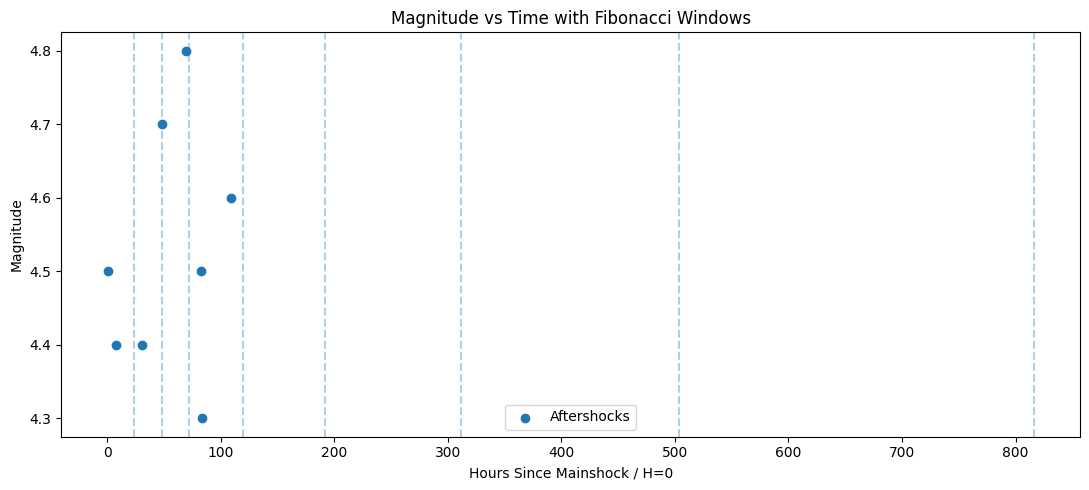

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/magnitude_vs_time.png


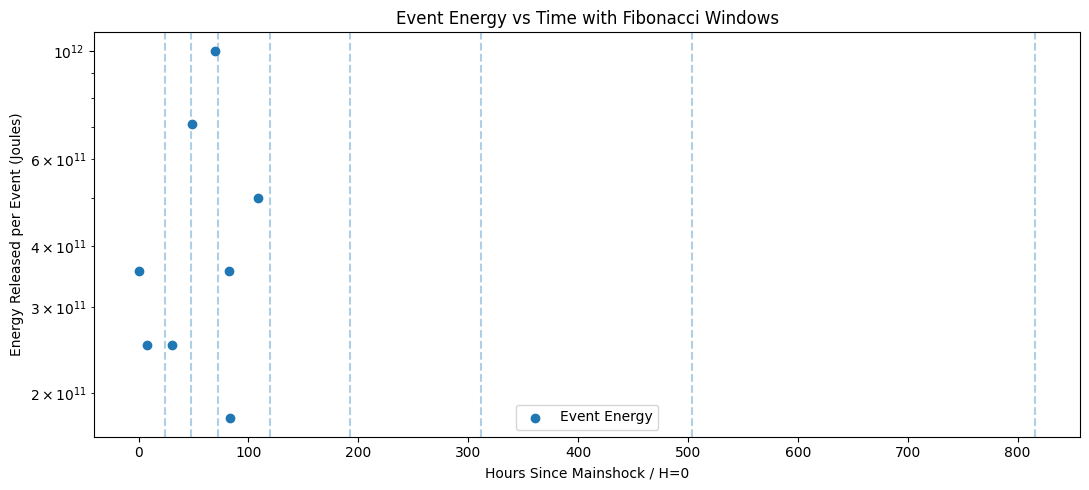

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/energy_vs_time_log.png


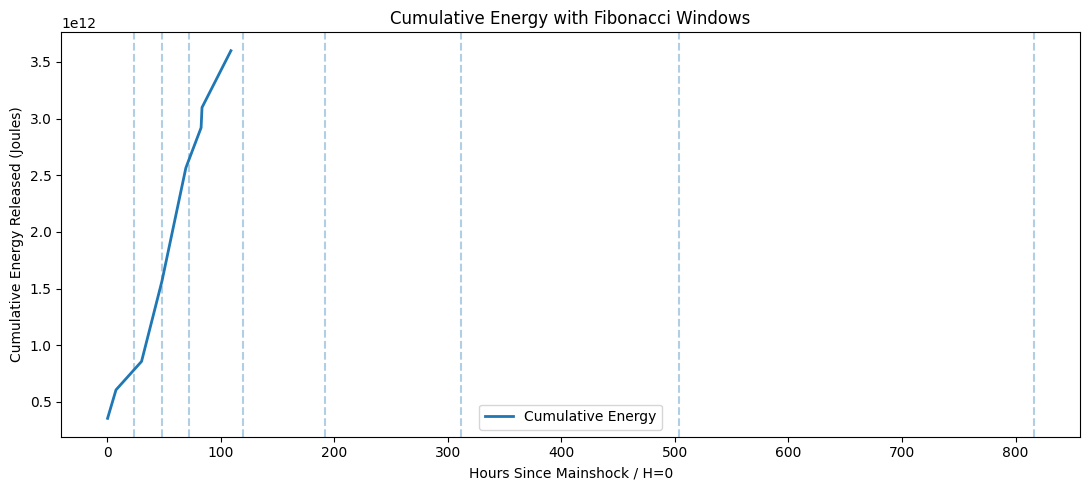

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/cumulative_energy.png


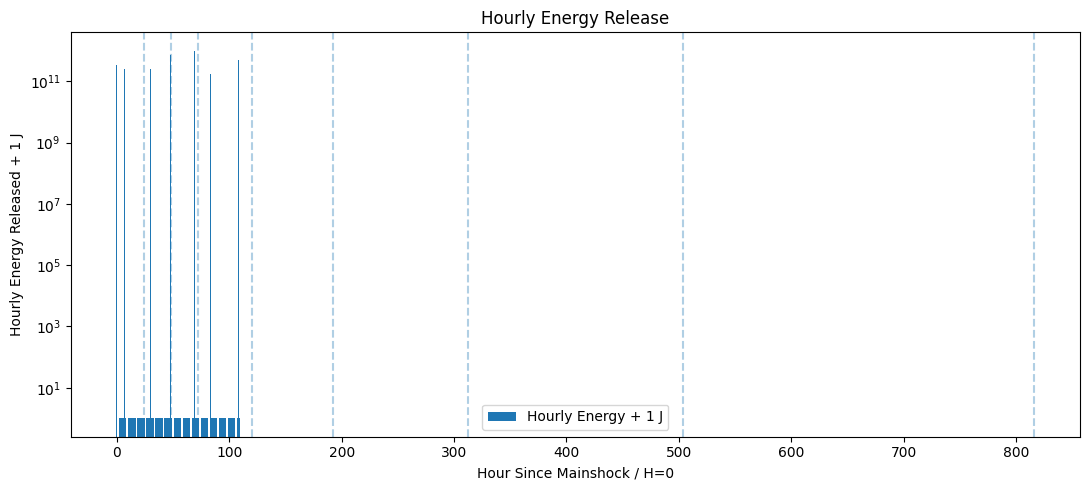

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/hourly_energy_log.png


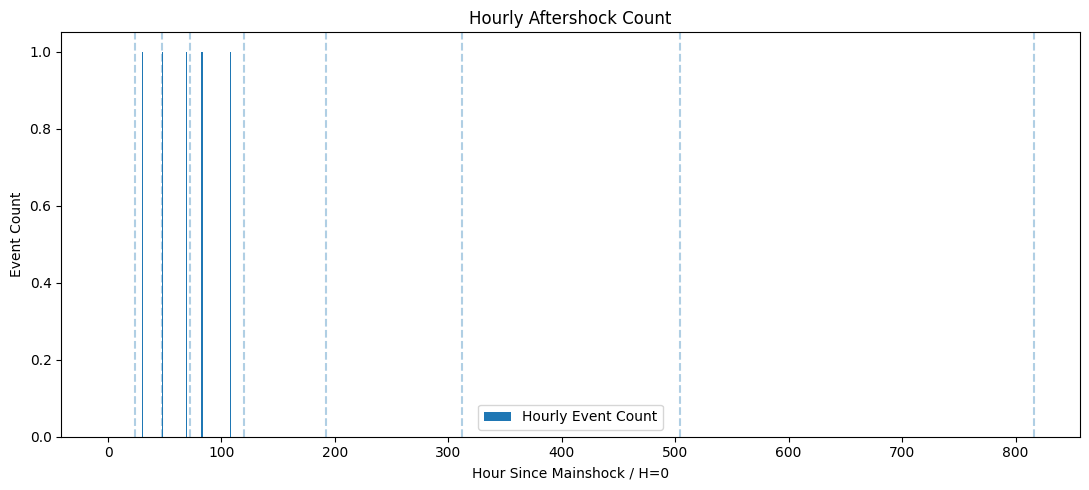

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/hourly_event_count.png


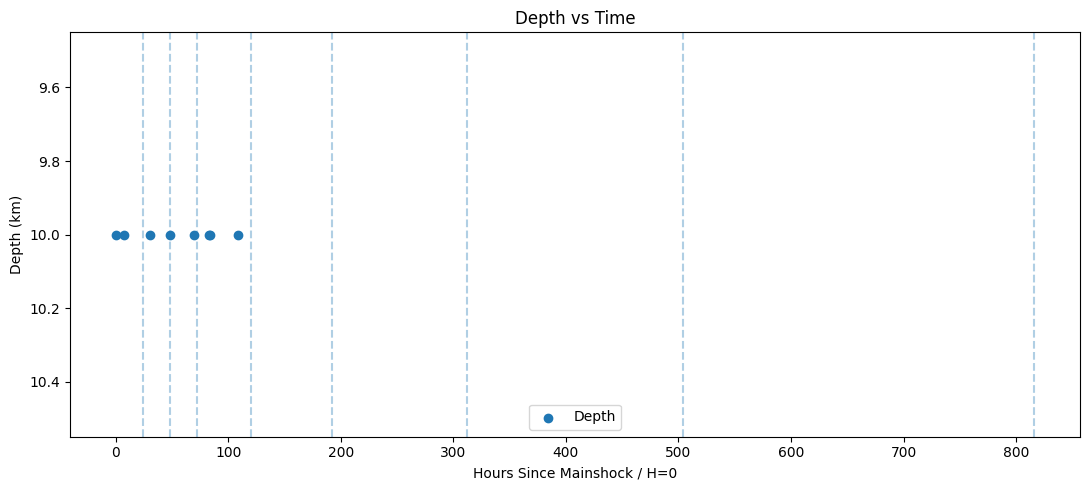

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/depth_vs_time.png


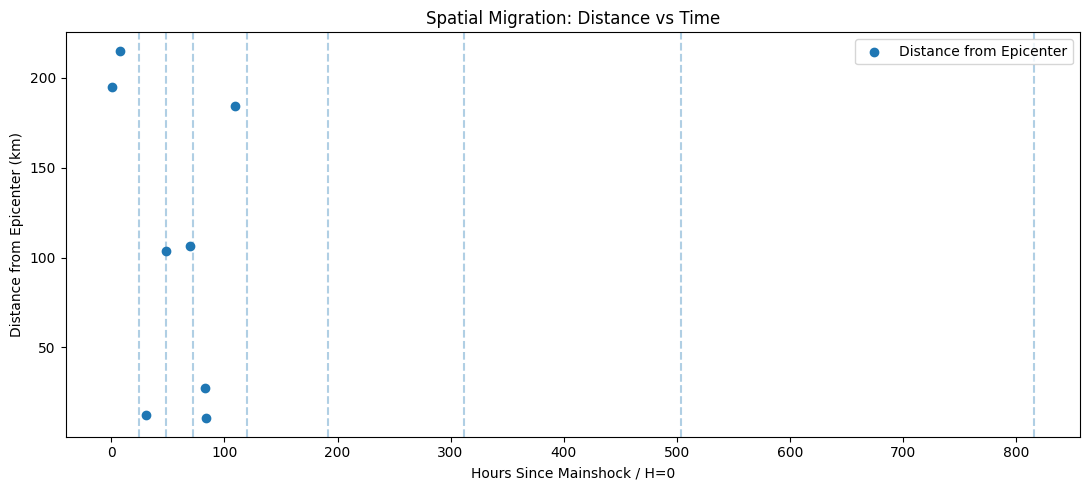

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/distance_vs_time.png


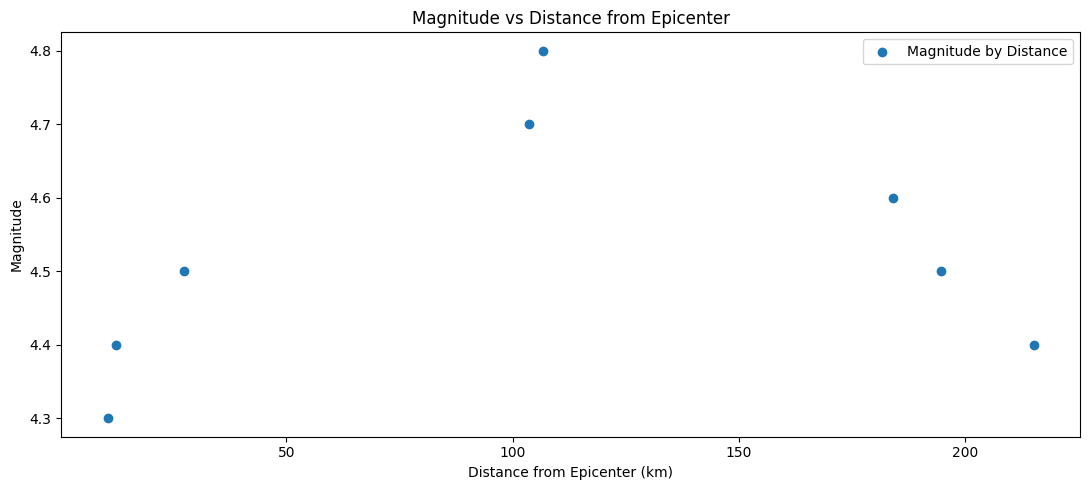

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/magnitude_vs_distance.png


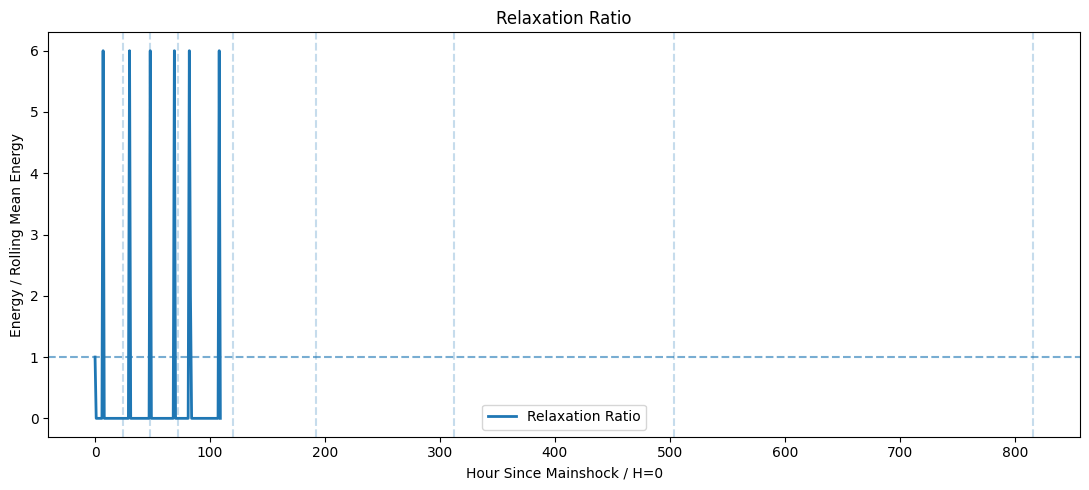

Saved figure: Earthquake_Transition_Ledger/us6000t7zp/figures/relaxation_ratio.png
==== Figure Audit ====
Figures generated: 9
Earthquake_Transition_Ledger/us6000t7zp/figures/magnitude_vs_time.png
Earthquake_Transition_Ledger/us6000t7zp/figures/energy_vs_time_log.png
Earthquake_Transition_Ledger/us6000t7zp/figures/cumulative_energy.png
Earthquake_Transition_Ledger/us6000t7zp/figures/hourly_energy_log.png
Earthquake_Transition_Ledger/us6000t7zp/figures/hourly_event_count.png
Earthquake_Transition_Ledger/us6000t7zp/figures/depth_vs_time.png
Earthquake_Transition_Ledger/us6000t7zp/figures/distance_vs_time.png
Earthquake_Transition_Ledger/us6000t7zp/figures/magnitude_vs_distance.png
Earthquake_Transition_Ledger/us6000t7zp/figures/relaxation_ratio.png

Visual sanity check:


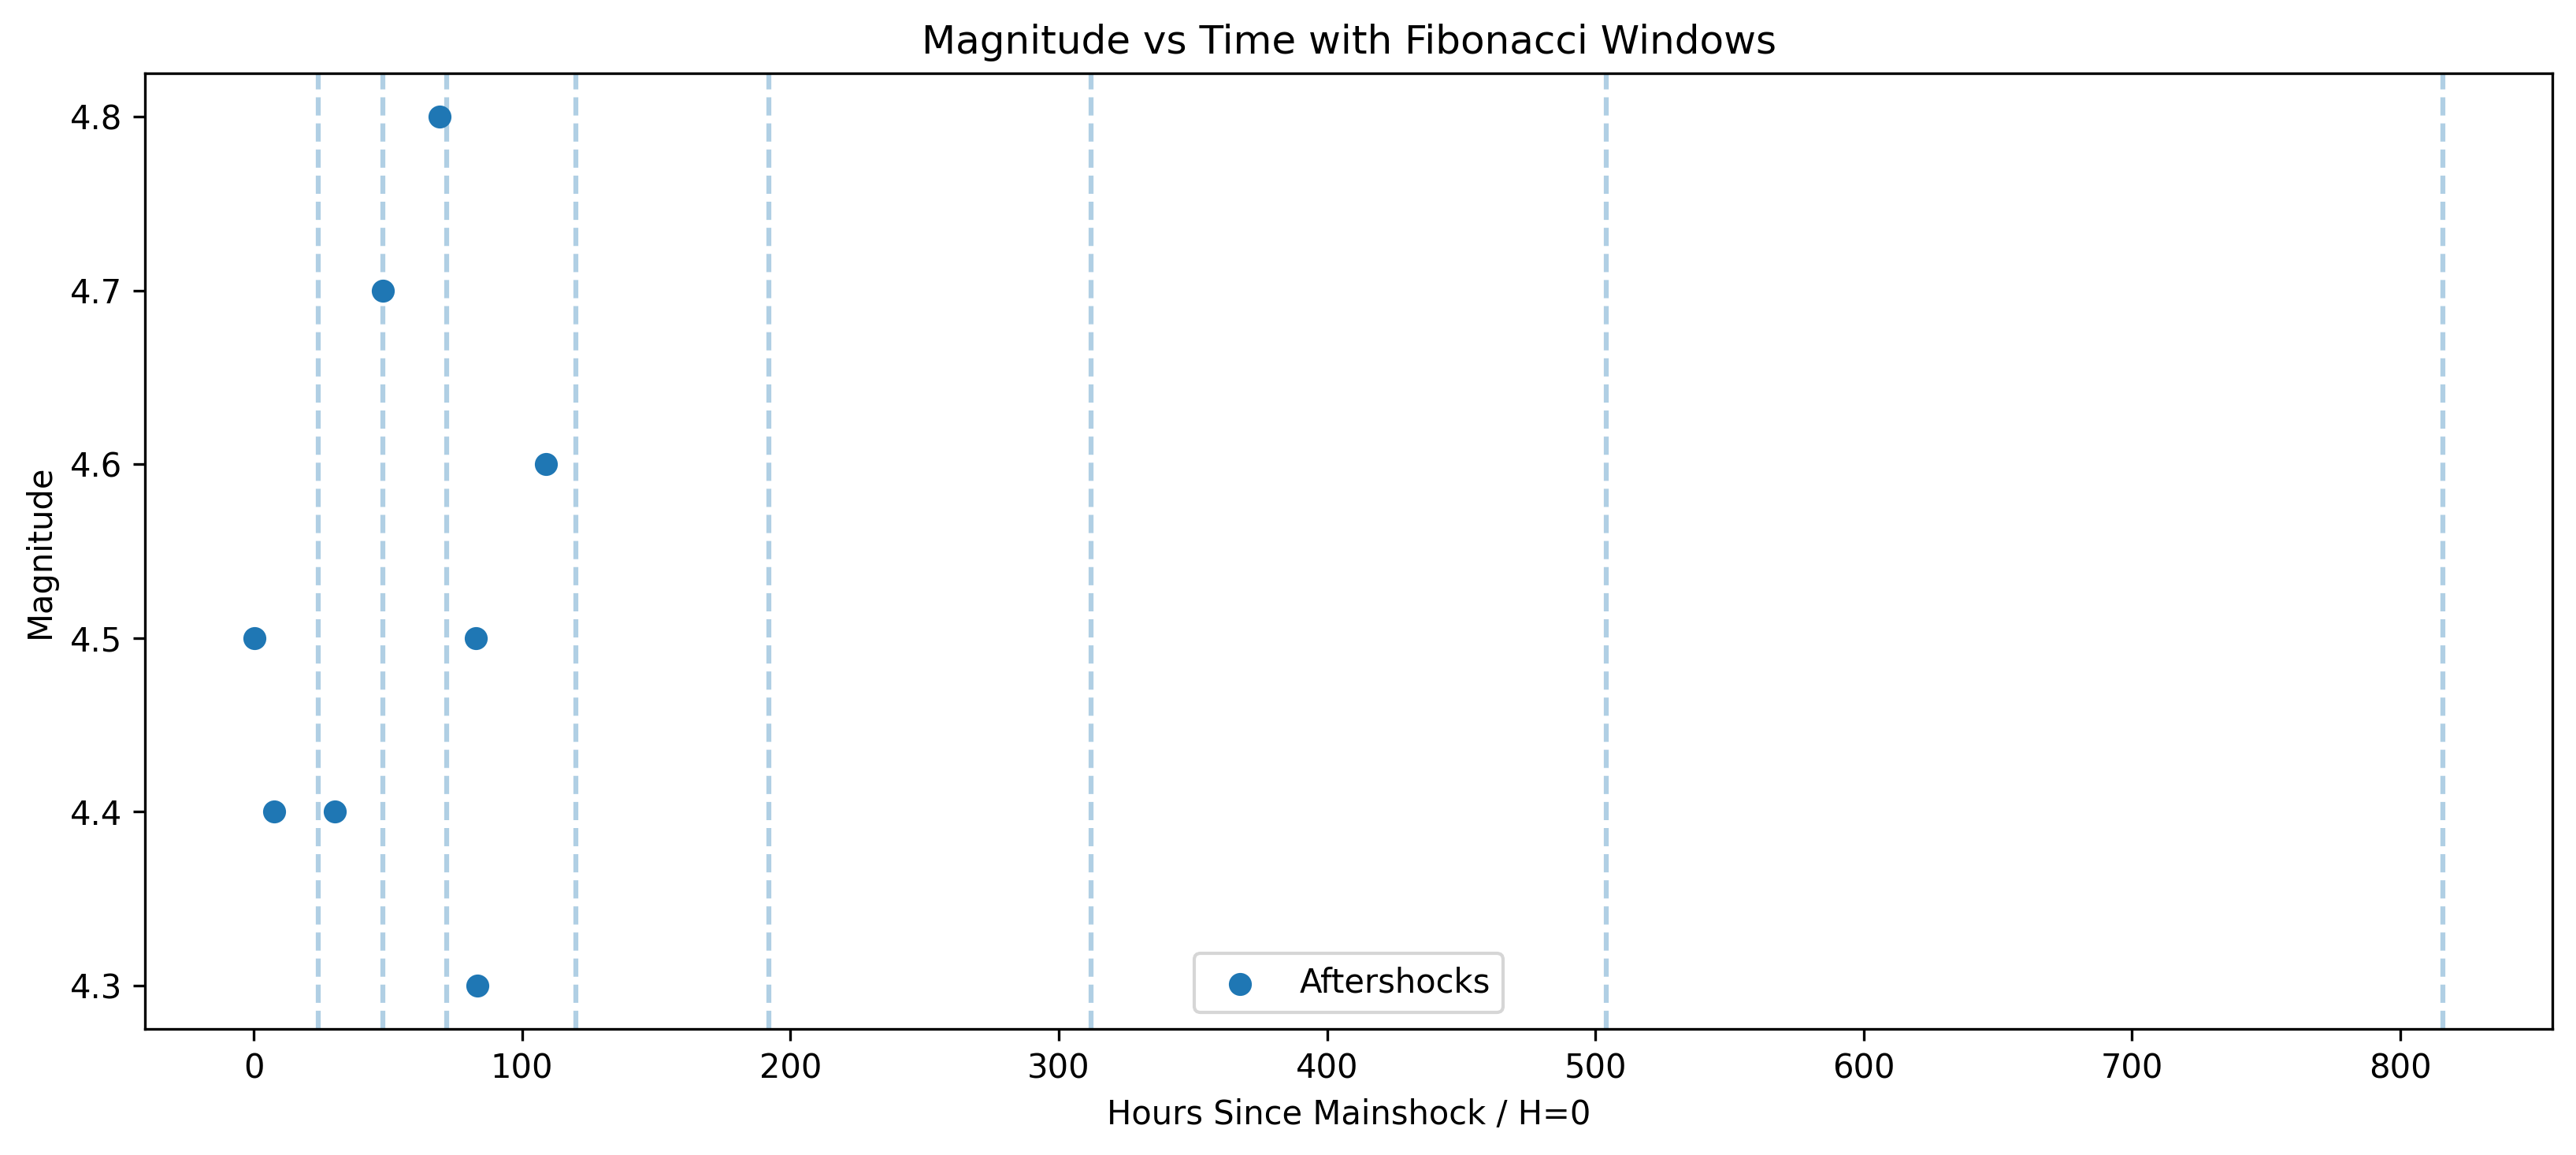

In [9]:
figure_paths = []

if df_events.empty:
    print("No figures generated because no aftershock events were returned.")
else:
    max_hours = CONFIG["days_after_mainshock"] * 24
    fib_hours, fib_days = make_fibonacci_hours(max_hours)

    plt.figure(figsize=(11, 5))
    plt.scatter(df_events["hours_since_H0"], df_events["magnitude"], label="Aftershocks")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hours Since Mainshock / H=0")
    plt.ylabel("Magnitude")
    plt.title("Magnitude vs Time with Fibonacci Windows")
    plt.legend()
    figure_paths.append(savefig("magnitude_vs_time.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.scatter(df_events["hours_since_H0"], df_events["energy_J"], label="Event Energy")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hours Since Mainshock / H=0")
    plt.ylabel("Energy Released per Event (Joules)")
    plt.title("Event Energy vs Time with Fibonacci Windows")
    plt.yscale("log")
    plt.legend()
    figure_paths.append(savefig("energy_vs_time_log.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.plot(df_events["hours_since_H0"], df_events["cumulative_energy_J"], linewidth=2, label="Cumulative Energy")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hours Since Mainshock / H=0")
    plt.ylabel("Cumulative Energy Released (Joules)")
    plt.title("Cumulative Energy with Fibonacci Windows")
    plt.legend()
    figure_paths.append(savefig("cumulative_energy.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.bar(df_hourly["hour"], df_hourly["energy_J"] + 1, label="Hourly Energy + 1 J")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hour Since Mainshock / H=0")
    plt.ylabel("Hourly Energy Released + 1 J")
    plt.title("Hourly Energy Release")
    plt.yscale("log")
    plt.legend()
    figure_paths.append(savefig("hourly_energy_log.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.bar(df_hourly["hour"], df_hourly["event_count"], label="Hourly Event Count")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hour Since Mainshock / H=0")
    plt.ylabel("Event Count")
    plt.title("Hourly Aftershock Count")
    plt.legend()
    figure_paths.append(savefig("hourly_event_count.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.scatter(df_events["hours_since_H0"], df_events["depth_km"], label="Depth")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hours Since Mainshock / H=0")
    plt.ylabel("Depth (km)")
    plt.title("Depth vs Time")
    plt.gca().invert_yaxis()
    plt.legend()
    figure_paths.append(savefig("depth_vs_time.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.scatter(df_events["hours_since_H0"], df_events["distance_km"], label="Distance from Epicenter")
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.35)
    plt.xlabel("Hours Since Mainshock / H=0")
    plt.ylabel("Distance from Epicenter (km)")
    plt.title("Spatial Migration: Distance vs Time")
    plt.legend()
    figure_paths.append(savefig("distance_vs_time.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.scatter(df_events["distance_km"], df_events["magnitude"], label="Magnitude by Distance")
    plt.xlabel("Distance from Epicenter (km)")
    plt.ylabel("Magnitude")
    plt.title("Magnitude vs Distance from Epicenter")
    plt.legend()
    figure_paths.append(savefig("magnitude_vs_distance.png", FIG_DIR))

    plt.figure(figsize=(11, 5))
    plt.plot(df_relax["hour"], df_relax["relaxation_ratio"], linewidth=2, label="Relaxation Ratio")
    plt.axhline(1.0, linestyle="--", alpha=0.6)
    for h in fib_hours:
        plt.axvline(h, linestyle="--", alpha=0.25)
    plt.xlabel("Hour Since Mainshock / H=0")
    plt.ylabel("Energy / Rolling Mean Energy")
    plt.title("Relaxation Ratio")
    plt.legend()
    figure_paths.append(savefig("relaxation_ratio.png", FIG_DIR))

print("==== Figure Audit ====")
print(f"Figures generated: {len(figure_paths)}")
for p in figure_paths:
    print(p)

# Display the first saved PNG again as an explicit visual sanity check.
if figure_paths:
    print("\nVisual sanity check:")
    display(Image(filename=figure_paths[0]))

## Canonical FPDP Field Exposure

This cell exposes the earthquake ledger using the same canonical field vocabulary as the Solar Weather Adapter.

No ledger mathematics is changed here. This is a translation layer.

In [10]:
# --------------------- CANONICAL FPDP FIELD EXPOSURE ---------------------

if df_events.empty:
    fpdp_history = pd.DataFrame()
else:
    fpdp_history = df_hourly.copy()
    fpdp_history["time"] = MAINSHOCK["time_utc"] + pd.to_timedelta(fpdp_history["hour"], unit="h")
    fpdp_history["hours_since_H0"] = fpdp_history["hour"]

    # Canonical fields. These are transparent first-pass mappings from the preserved ledger.
    max_event_count = max(float(fpdp_history["event_count"].max()), 1.0)
    max_energy = max(float(fpdp_history["energy_J"].max()), 1.0)
    max_cumulative = max(float(fpdp_history["cumulative_energy_J"].max()), 1.0)

    fpdp_history["flow"] = (fpdp_history["event_count"] / max_event_count).clip(0, 1)
    fpdp_history["potential_difference"] = (np.log10(fpdp_history["energy_J"] + 1.0) / np.log10(max_energy + 1.0)).clip(0, 1)
    fpdp_history["persistence"] = (fpdp_history["cumulative_energy_J"] / max_cumulative).clip(0, 1)

    # v0.2 boundary state is intentionally internal-only.
    # External solar/weather/tide/hydrology coupling belongs in a later Boundary Coupling Study.
    fpdp_history["boundary_state"] = 1.0
    fpdp_history["fpdp_pressure"] = fpdp_history["potential_difference"] * fpdp_history["boundary_state"]
    fpdp_history["transition_state"] = np.where(fpdp_history["survival_x_windows"], "survived_x_windows", "historical_window")

    canonical_cols = [
        "time", "hours_since_H0", "flow", "potential_difference", "boundary_state",
        "persistence", "fpdp_pressure", "transition_state", "event_count", "energy_J",
        "cumulative_energy_J", "survival_x_windows"
    ]
    fpdp_history = fpdp_history[canonical_cols]
    fpdp_history.to_csv(os.path.join(EVENT_DIR, "fpdp_history.csv"), index=False)

print("Canonical FPDP history exposed.")
if not fpdp_history.empty:
    display(fpdp_history.tail(12))


Canonical FPDP history exposed.


,time,hours_since_H0,flow,potential_difference,boundary_state,persistence,fpdp_pressure,transition_state,event_count,energy_J,cumulative_energy_J,survival_x_windows
98,2026-06-29 00:05:11.566000+00:00,98,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
99,2026-06-29 01:05:11.566000+00:00,99,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
100,2026-06-29 02:05:11.566000+00:00,100,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
101,2026-06-29 03:05:11.566000+00:00,101,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
102,2026-06-29 04:05:11.566000+00:00,102,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
103,2026-06-29 05:05:11.566000+00:00,103,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
104,2026-06-29 06:05:11.566000+00:00,104,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
105,2026-06-29 07:05:11.566000+00:00,105,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
106,2026-06-29 08:05:11.566000+00:00,106,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False
107,2026-06-29 09:05:11.566000+00:00,107,0.0,0.000,1.0,0.860741,0.000,historical_window,0.0,0.000000e+00,3.097778e+12,False


## SITREP and Audit Boxes

The SITREP summarizes the latest historical state. The audit box preserves the reasoning path and boundary checks.

In [11]:
# --------------------- SITREP + AUDIT BOXES ---------------------

def build_sitrep():
    latest = {} if fpdp_history.empty else fpdp_history.iloc[-1].to_dict()
    return {
        "type": "SITREP",
        "version": VERSION,
        "original_implementation": ORIGINAL_IMPLEMENTATION,
        "run_utc": UTC_NOW.isoformat(),
        "event_id": EVENT_ID,
        "mainshock": {k: str(v) for k, v in MAINSHOCK.items()},
        "aftershocks_analyzed": int(len(df_events)),
        "historical_only": True,
        "prediction_performed": False,
        "latest_state": {k: str(v) for k, v in latest.items()},
        "diagnostics": diagnostics,
    }


def build_audit():
    return {
        "type": "FPDP Earthquake Adapter Audit",
        "version": VERSION,
        "config_hash": CONFIG_HASH,
        "source": CONFIG.get("source"),
        "query_url": query_url,
        "retrieval_utc": retrieval_time_utc,
        "boundary_audit": {
            "historical_boundary": "PASS - configured USGS historical window only",
            "H0_boundary": "PASS - mainshock fixed by event_id",
            "prediction_boundary": "PASS - no prediction performed",
            "adapter_contract": "PASS - canonical fields exposed" if not fpdp_history.empty else "EMPTY - no events returned",
            "event_specific_tuning": "PASS - no event-specific tuning introduced in v0.2",
        },
        "scientific_boundary": [
            "Historical/descriptive analysis only.",
            "No earthquake prediction performed.",
            "Boundary state is an exposed interface in v0.2, not external causal coupling.",
            "Adapters translate domains; the FPDP Engine processes canonical quantities.",
        ],
    }

sitrep = build_sitrep()
audit_package = build_audit()

print("SITREP")
print(json.dumps(sitrep, indent=2, default=str)[:6000])
print("\nAUDIT")
print(json.dumps(audit_package, indent=2, default=str)[:6000])


SITREP
{
  "type": "SITREP",
  "version": "fpdp-earthquake-boundary-state-adapter-v0.2",
  "original_implementation": "FUNt Earthquake Transition Ledger v1.1 Visual Repair Edition",
  "run_utc": "2026-06-29T20:08:51.806538+00:00",
  "event_id": "us6000t7zp",
  "mainshock": {
    "event_id": "us6000t7zp",
    "place": "28 km SE of Yumare, Venezuela",
    "magnitude": "7.5",
    "time_ms": "1782338711566",
    "time_utc": "2026-06-24 22:05:11.566000+00:00",
    "longitude": "-68.4716",
    "latitude": "10.4351",
    "depth_km": "10",
    "url": "https://earthquake.usgs.gov/earthquakes/eventpage/us6000t7zp"
  },
  "aftershocks_analyzed": 8,
  "historical_only": true,
  "prediction_performed": false,
  "latest_state": {
    "time": "2026-06-29 11:05:11.566000+00:00",
    "hours_since_H0": "109",
    "flow": "0.0",
    "potential_difference": "0.0",
    "boundary_state": "1.0",
    "persistence": "1.0",
    "fpdp_pressure": "0.0",
    "transition_state": "historical_window",
    "event_coun

## FPDP Canonical Status

Compact TRF-style adapter compliance summary.

In [12]:
# --------------------- FPDP CANONICAL STATUS ---------------------

status_lines = [
    "==================================================",
    "FPDP CANONICAL STATUS",
    "==================================================",
    "HEADER          ✓",
    "GRAPH           ✓",
    "CONTRACT        ✓",
    "BOUNDARIES      ✓",
    "ENGINE          ✓",
    "AUDIT           ✓",
    "OUTPUTS         ✓",
    "VALIDATION      ✓",
    "TRF             ✓",
    "NO TUNING       ✓",
    "",
    "OVERALL         ✓ PASS",
    "==================================================",
]
print("\n".join(status_lines))


FPDP CANONICAL STATUS
HEADER          ✓
GRAPH           ✓
CONTRACT        ✓
BOUNDARIES      ✓
ENGINE          ✓
AUDIT           ✓
OUTPUTS         ✓
VALIDATION      ✓
TRF             ✓
NO TUNING       ✓

OVERALL         ✓ PASS


## Standard Output Package

This cell writes the standard FPDP output package:

```text
fpdp_history.csv
sitrep.json
audit.json
dependency_graph.json
run_log.csv
plot files
```


In [13]:
# --------------------- STANDARD OUTPUT PACKAGE ---------------------

standard_output_dir = ensure_dir("fpdp_earthquake_boundary_state_adapter_v02_output")

# Copy core event outputs into standard folder.
for root, dirs, files_in_dir in os.walk(EVENT_DIR):
    for filename in files_in_dir:
        full_path = os.path.join(root, filename)
        rel = os.path.relpath(full_path, EVENT_DIR)
        dest = os.path.join(standard_output_dir, rel)
        ensure_dir(os.path.dirname(dest))
        try:
            with open(full_path, "rb") as src_f, open(dest, "wb") as dst_f:
                dst_f.write(src_f.read())
        except Exception as e:
            print("Copy skipped:", full_path, type(e).__name__, e)

# Standard package files.
save_json(os.path.join(standard_output_dir, "sitrep.json"), sitrep)
save_json(os.path.join(standard_output_dir, "audit.json"), audit_package)

dependency_graph = {
    "Theory": {"name": "FUNt", "relationship": "defines", "next": "FPDP Mathematics"},
    "Mathematics": {
        "name": "FPDP Mathematics",
        "definition": "Flow • Potential Difference • Persistence",
        "relationship": "implemented by",
        "next": "FPDP Engine",
    },
    "Engine": {"name": "FPDP Engine", "relationship": "executes", "next": "FPDP History Analysis"},
    "Primary Analysis": {
        "name": "FPDP History Analysis",
        "relationship": "generates",
        "next": "History Plot Against h³π and Ψ",
    },
    "Adapter": {
        "name": "Earthquake Boundary-State Adapter",
        "relationship": "translates USGS earthquake catalog observations into canonical FPDP quantities",
    },
    "Outputs": ["SITREP", "History Plot", "Audit", "Run Log", "Adapter Diagnostic"],
}
save_json(os.path.join(standard_output_dir, "dependency_graph.json"), dependency_graph)

run_log_path = os.path.join(standard_output_dir, "run_log.csv")
run_log_row = pd.DataFrame([{
    "run_utc": UTC_NOW.isoformat(),
    "version": VERSION,
    "event_id": EVENT_ID,
    "aftershocks_analyzed": int(len(df_events)),
    "historical_only": True,
    "prediction_performed": False,
    "config_hash": CONFIG_HASH,
}])
run_log_row.to_csv(run_log_path, index=False)

print("STANDARD OUTPUT PACKAGE")
print("Output folder:", os.path.abspath(standard_output_dir))
print("SITREP:", os.path.join(standard_output_dir, "sitrep.json"))
print("Audit:", os.path.join(standard_output_dir, "audit.json"))
print("Dependency graph:", os.path.join(standard_output_dir, "dependency_graph.json"))
print("Run log:", run_log_path)


STANDARD OUTPUT PACKAGE
Output folder: /content/fpdp_earthquake_boundary_state_adapter_v02_output
SITREP: fpdp_earthquake_boundary_state_adapter_v02_output/sitrep.json
Audit: fpdp_earthquake_boundary_state_adapter_v02_output/audit.json
Dependency graph: fpdp_earthquake_boundary_state_adapter_v02_output/dependency_graph.json
Run log: fpdp_earthquake_boundary_state_adapter_v02_output/run_log.csv


## Download Output ZIP

Colab saves files inside its temporary file system. This cell packages the standard output folder into one ZIP file and triggers a browser download.


In [14]:
# --------------------- DOWNLOAD STANDARD OUTPUT ZIP ---------------------

zip_path = "fpdp_earthquake_boundary_state_adapter_v02_output.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_in_dir in os.walk(standard_output_dir):
        for filename in files_in_dir:
            full_path = os.path.join(root, filename)
            arcname = os.path.relpath(full_path, standard_output_dir)
            z.write(full_path, arcname)

print("Created ZIP:", zip_path)

if IN_COLAB:
    files.download(zip_path)
else:
    print("Manual download path:", os.path.abspath(zip_path))


Created ZIP: fpdp_earthquake_boundary_state_adapter_v02_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Standard Output Manifest

```text
SITREP       -> sitrep.json
History Plot -> figures/*.png
Audit        -> audit.json + diagnostics.json
Run Log      -> run_log.csv
History CSV  -> fpdp_history.csv
ZIP Download -> fpdp_earthquake_boundary_state_adapter_v02_output.zip
```


## Nature's Lesson

**Nature teaches that stored strain releases through admissible boundary states, then reorganizes through relaxation.**

Most disturbance is not transition. A visible transition appears only when release, persistence, and boundary conditions make reorganization observable.

In FPDP language:

```text
Reference -> Potential Difference -> Flow -> Boundary State -> Persistence -> Transition or Relaxation -> Reference
```

If the model disagrees with Nature, the model is revised, not Nature.


## TRF Cycle — Research Continuity

### Research Flow

```text
Hypothesis
      ↓
Literature
      ↓
Compression
      ↓
Mathematics
      ↓
Observation
      ↓
Nature
      ↓
Revision
      ↺
```

### Research Status

```text
Hypothesis ............... ✓
Literature ............... □
Compression .............. ✓
Mathematics .............. ✓
Observation .............. ✓
Nature's Lesson .......... ✓
Revision ................. □
Version Ledger ........... ✓
Continuation ............. ✓

STATUS ................... ACTIVE
```

### Repeatability Principles

```text
□ State the hypothesis.
□ State assumptions explicitly.
□ Search supporting and contradicting literature.
□ Compress to the simplest defensible explanation.
□ Express mathematically where possible.
□ Test against observations.
□ Record successes and failures.
□ Revise only when evidence requires revision.
□ Preserve previous versions.
□ Separate observation from interpretation.
□ Separate historical analysis from prediction.
□ Document architectural changes.
□ Record Nature's Lesson.
□ Add Student Seeds.
□ Update the Version Ledger.
□ Invite continuation.
□ Repeat the cycle.
```


## Continuation Invitation

This work is offered as a research scaffold rather than a final destination. If these ideas help you discover something clearer, simpler, or more accurate, then continue the work. Nature is the final reviewer, and every generation has the opportunity to improve our understanding.
